In [1]:
import joblib
rsh = joblib.load('/home/shic892/corems/gradient_nmf_log_top_respiration_log.pkl')
rsh.best_score_

-1.048461013941341

In [2]:
rsh.scorer_

make_scorer(mean_squared_error, greater_is_better=False, squared=False)

In [1]:
import pandas as pd
import numpy as np

df_sites_qc = pd.read_csv('/home/shic892/corems/1000_soils_124x7880_122122.csv', index_col=0)
site_depth = [x[5:8] for x in df_sites_qc.index.values]
df_sites_qc_top = df_sites_qc.iloc[[x=='TOP' for x in site_depth],:]
df_sites_qc_top = df_sites_qc_top.loc[:,df_sites_qc_top.sum()>0]
df_sites_qc_btm = df_sites_qc.iloc[[x=='BTM' for x in site_depth],:]
df_sites_qc_btm = df_sites_qc_btm.loc[:,df_sites_qc_btm.sum()>0]
df_env = pd.read_csv('/home/shic892/corems/1000s_env_w_biome_meta_v4.csv', index_col = 0,encoding='latin-1')
df_env.columns = [x[0:10] for x in df_env.columns]

df_env = df_env.iloc[:,np.append(range(0,28), range(56,61))]
df_env = df_env.drop(['TKN_pct'], axis=1)
df_env['Total_Carb'] = np.log10(df_env['Total_Carb']+1)
df_env['Total_Nitr'] = np.log10(df_env['Total_Nitr']+1)
df_env['C_to_N_rat'] = np.log10(df_env['C_to_N_rat']+1)

df_env_top = df_env.loc[df_sites_qc_top.index.values,:]
df_env_btm = df_env.loc[df_sites_qc_btm.index.values,:]

df_env_top_pred = df_env_top.iloc[:,np.append(range(0,21), range(24,32))]
df_env_top_pred = df_env_top_pred.fillna(0.)
df_env_btm_pred = df_env_btm.iloc[:,np.append(range(0,21), range(24,32))]
df_env_btm_pred = df_env_btm.fillna(0.)

df_env_top_pred = df_env_top_pred.loc[:,['mean_GWC', 'Mn_mg_per_','CEC_Meq_pe',  'Total_Nitr','Total_Carb']]
df_env_btm_pred = df_env_btm_pred.loc[:,['mean_GWC', 'Mg_Meq_per','Total_Base', 'CEC_Meq_pe',  'Total_Nitr','Total_Carb']]

In [2]:
results_loc = '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt/7/'
# '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt'
# '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt
datah0 = np.load(results_loc+'H_reg_factors/H_0.npy')
print(datah0.shape)
datah1 = np.load(results_loc+'H_reg_factors/H_1.npy')
print(datah1.shape)
datah2 = np.load(results_loc+'H_reg_factors/H_2.npy')
print(datah2.shape)
datah3 = np.load(results_loc+'H_reg_factors/H_3.npy')
print(datah3.shape)
datah7 = np.concatenate((datah0,datah1,datah2,datah3), axis=1)
#np.savetxt('1000s_nmf_9_H_124.csv', data, delimiter=',')
print(datah7.shape)

results_loc = '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt/5/'
# '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt'
# '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt
datah0 = np.load(results_loc+'H_reg_factors/H_0.npy')
print(datah0.shape)
datah1 = np.load(results_loc+'H_reg_factors/H_1.npy')
print(datah1.shape)
datah2 = np.load(results_loc+'H_reg_factors/H_2.npy')
print(datah2.shape)
datah3 = np.load(results_loc+'H_reg_factors/H_3.npy')
print(datah3.shape)
datah5 = np.concatenate((datah0,datah1,datah2,datah3), axis=1)
#np.savetxt('1000s_nmf_9_H_124.csv', data, delimiter=',')
print(datah5.shape)

(7, 16)
(7, 16)
(7, 16)
(7, 15)
(7, 63)
(5, 16)
(5, 15)
(5, 15)
(5, 15)
(5, 61)


In [3]:
from sklearn.model_selection import train_test_split

X, y = np.log(datah7.T+1), np.log(df_env_top['Respiratio'].iloc[:,1].values+1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

In [4]:
np.savetxt("top_nmf_train.csv", X_train, delimiter=',')
np.savetxt("top_nmf_test.csv", X_test, delimiter=',')

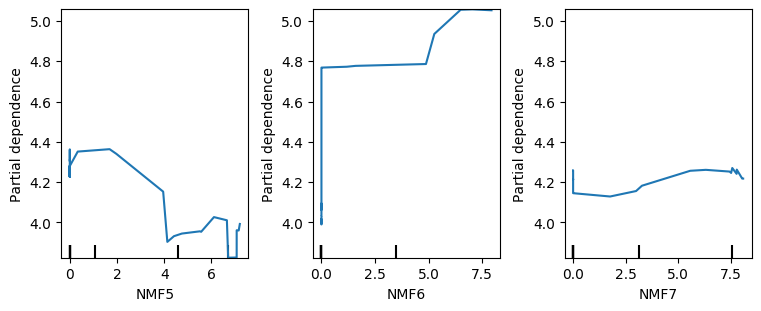

In [48]:
from sklearn.inspection import PartialDependenceDisplay
_, ax = plt.subplots(ncols=3, nrows=1, figsize=(7.5, 3), constrained_layout=True)
PartialDependenceDisplay.from_estimator(rsh.best_estimator_, X_train, 
                                        np.arange(4,7),feature_names=['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5','NMF6','NMF7'],method="brute",
                                        ax=ax)
plt.show()

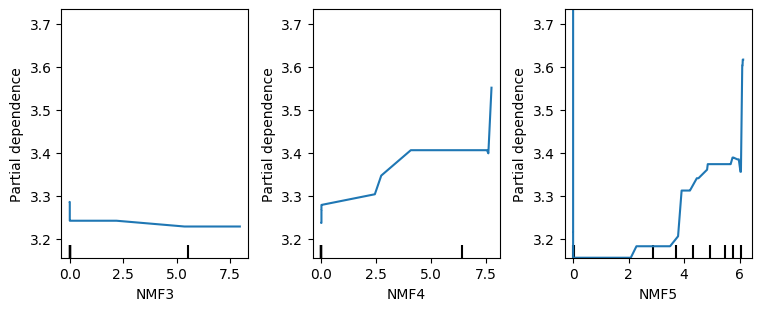

In [23]:
from sklearn.inspection import PartialDependenceDisplay
rsh = joblib.load('/home/shic892/corems/gradient_env_6_nmf_5_log_btm_respiration_log_v1_final.pkl')
df_env_btm_pred[['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5']] = np.log(datah5.T+1)
X, y = df_env_btm_pred.values, np.log(df_env_btm['Respiratio'].iloc[:,1].values+1)
#df_env_btm_pred.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
_, ax = plt.subplots(ncols=3, nrows=1, figsize=(7.5, 3), constrained_layout=True)
PartialDependenceDisplay.from_estimator(rsh.best_estimator_, X_train, 
                                        np.arange(8,11),feature_names=df_env_btm_pred.columns,method="brute",
                                        ax=ax)
plt.show()

In [56]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, expon
from sklearn.ensemble import GradientBoostingRegressor
rng = np.random.RandomState(0)

clf = GradientBoostingRegressor(random_state=rng)

param_dist = {
    "loss": ['squared_error','absolute_error', 'huber'],
    "n_estimators": randint(50,2000),
    "max_depth": randint(5,63),
    "max_features": ['auto', 'sqrt', 'log2', 1,2,3,4,5],
    "min_samples_split": randint(2, 10),
    "criterion": ['friedman_mse', 'squared_error'],
    "learning_rate": [0.0001, 0.001, 0.01, 0.1, 1.0],
    "ccp_alpha" : expon(scale=0.1)
}

rsh = RandomizedSearchCV(
    estimator=clf, param_distributions=param_dist,random_state=rng, n_iter=1000,return_train_score=True, 
     cv=5, scoring="neg_root_mean_squared_error", 
)
rsh.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=GradientBoostingRegressor(random_state=RandomState(MT19937) at 0x2B7237271258),
                   n_iter=1000,
                   param_distributions={'ccp_alpha': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b7236f01eb8>,
                                        'criterion': ['friedman_mse',
                                                      'squared_error'],
                                        'learning_rate': [0.0001, 0.001, 0.01,
                                                          0.1, 1.0],
                                        'loss': ['squared_error',
                                                 'absolute_err...
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b7236f01a90>,
                                        'max_features': ['auto', 'sqrt', 'log2',
                                                         1, 2, 3, 4, 5],
        

Text(0, 0.5, 'predicted')

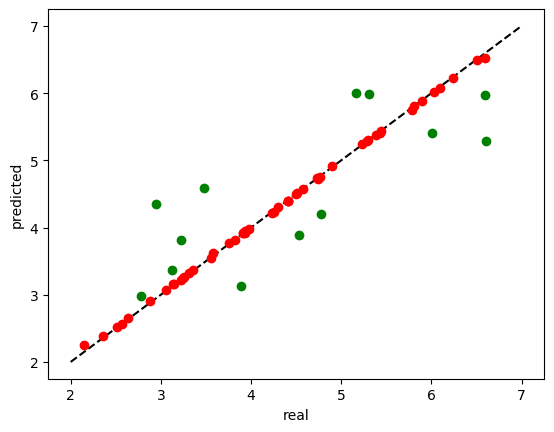

In [8]:
from matplotlib import pyplot as plt

plt.plot([2, 7], [2, 7], 'k--')
plt.plot(    y_train,     rsh.best_estimator_.predict(X_train[:,0:15]),     c="r",     marker='o', linewidth=0 )
plt.plot( y_test,    rsh.best_estimator_.predict(X_test[:,0:15]),    c="g",    marker='o', linewidth=0)
plt.xlabel("real")
plt.ylabel("predicted")

In [58]:
rsh.best_estimator_.score(X_test,y_test)

0.47187942481223555

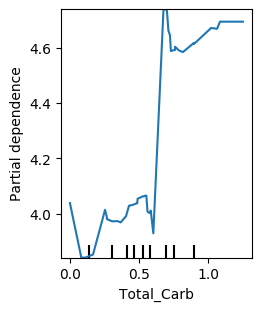

In [60]:
_, ax = plt.subplots(ncols=1, nrows=1, figsize=(2.5, 3), constrained_layout=True)
PartialDependenceDisplay.from_estimator(rsh.best_estimator_, X_train, 
                                        np.arange(4,5),feature_names=df_env_top_pred.columns,method="brute",
                                        ax=ax)
plt.show()

Text(0.5, 1.0, 'Feature Importance (MDI)')

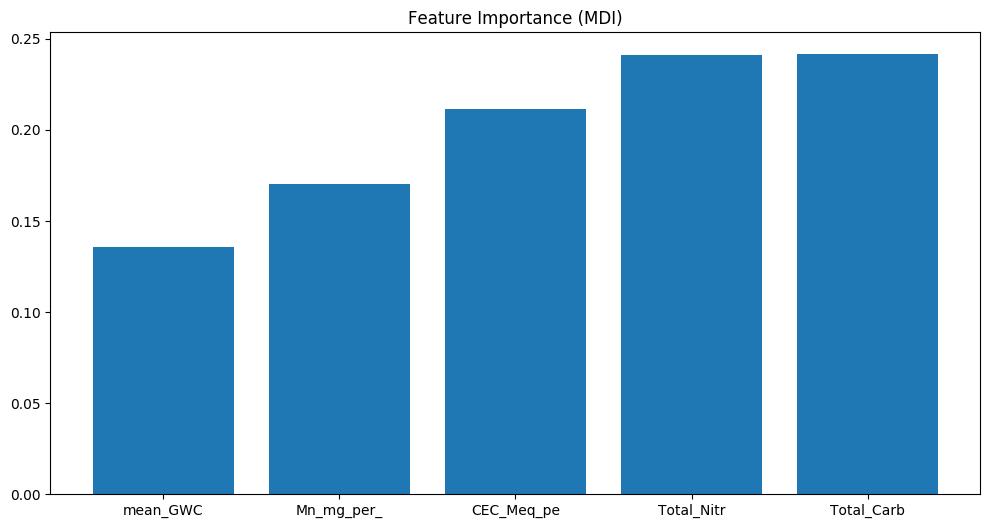

In [63]:
feature_importance = rsh.best_estimator_.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(12, 6))

plt.bar(pos, feature_importance[sorted_idx], align="center")
plt.xticks(pos, np.array(df_env_top_pred.iloc[:,0:15].columns)[sorted_idx])
plt.title("Feature Importance (MDI)")

In [64]:
joblib.dump(rsh, '/home/shic892/corems/gradient_env_5_top_respiration_log_vnnn.pkl')

['/home/shic892/corems/gradient_env_5_top_respiration_log_vnnn.pkl']

In [6]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, rsh.best_estimator_.predict(X_test), squared=False)

0.8906801637081007

In [7]:
mean_squared_error(y_train, rsh.best_estimator_.predict(X_train), squared=False)

0.3232417792617265

In [16]:
rsh1 = joblib.load('/home/shic892/corems/gradient_nmf_5_log_btm_respiration_log_v2.pkl')

In [5]:
X, y = np.log(datah5.T+1), np.log(df_env_btm['Respiratio'].iloc[:,1].values+1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [6]:
np.savetxt("btm_nmf_train.csv", X_train, delimiter=',')
np.savetxt("btm_nmf_test.csv", X_test, delimiter=',')

In [22]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, expon
from sklearn.ensemble import GradientBoostingRegressor
rng = np.random.RandomState(0)

clf = GradientBoostingRegressor(random_state=rng)

param_dist = {
    "loss": ['squared_error','absolute_error'],
    "n_estimators": randint(50,3000),
    "max_depth": randint(2,60),
    "max_features": ['auto', 'sqrt', 'log2', 2,3,4,5],
    "min_samples_leaf": randint(1,20),
    "min_samples_split": randint(2, 10),
    #"criterion": ['friedman_mse', 'squared_error'],
    "learning_rate": [0.0001, 0.001, 0.01, 0.1, 1.0],
    "ccp_alpha" : expon(scale=0.1)
}

rsh = RandomizedSearchCV(
    estimator=clf, param_distributions=param_dist,random_state=rng, n_iter=1000,return_train_score=True, 
     cv=5,  scoring="neg_root_mean_squared_error", 
)
rsh.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=GradientBoostingRegressor(random_state=RandomState(MT19937) at 0x2B58E7983A98),
                   n_iter=1000,
                   param_distributions={'ccp_alpha': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b58eaefcba8>,
                                        'learning_rate': [0.0001, 0.001, 0.01,
                                                          0.1, 1.0],
                                        'loss': ['squared_error',
                                                 'absolute_error'],
                                        'max_depth': <scipy.stats._distn_infrastr...
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b58ea60f780>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b58eaefca58>,
                                        'n_estimators': <scipy.stats._distn_i

In [24]:
rsh.best_score_

-0.8161553803623794

In [23]:
rsh.best_estimator_.score(X_test,y_test)

-0.7149868485358002

In [26]:
mean_squared_error(y_test, rsh.best_estimator_.predict(X_test), squared=False)

0.8033732060229514

Text(0, 0.5, 'predicted')

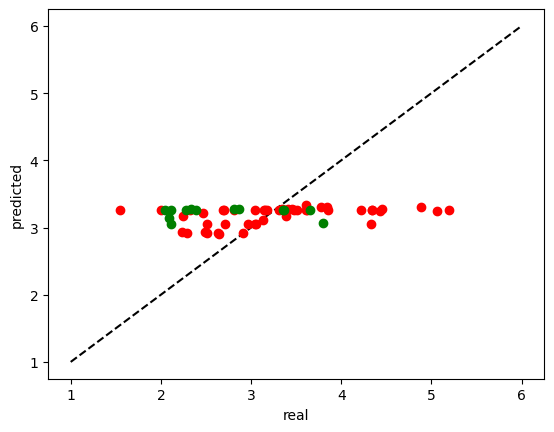

In [27]:
from matplotlib import pyplot as plt
y_hat = rsh.best_estimator_.predict(X_test)

plt.plot([1, 6], [1, 6], 'k--')
plt.plot(
    y_train,
    rsh.best_estimator_.predict(X_train),
    c="r",
    marker='o', linewidth=0
)
plt.plot(y_test,    rsh.best_estimator_.predict(X_test),    c="g",    marker='o', linewidth=0)
plt.xlabel("real")
plt.ylabel("predicted")

In [29]:
joblib.dump(rsh, '/home/shic892/corems/gradient_nmf_5_log_btm_respiration_log_v3.pkl')

['/home/shic892/corems/gradient_nmf_5_log_btm_respiration_log_v3.pkl']

In [107]:
rsh = joblib.load('/home/shic892/corems/gradient_env_5_nmf_7_log_top_respiration_log_v1.pkl')

In [108]:
df_env_top_pred[['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5', 'NMF6', 'NMF7']] = np.log(datah7.T+1)
X, y = df_env_top_pred.values, np.log(df_env_top['Respiratio'].iloc[:,1].values+1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

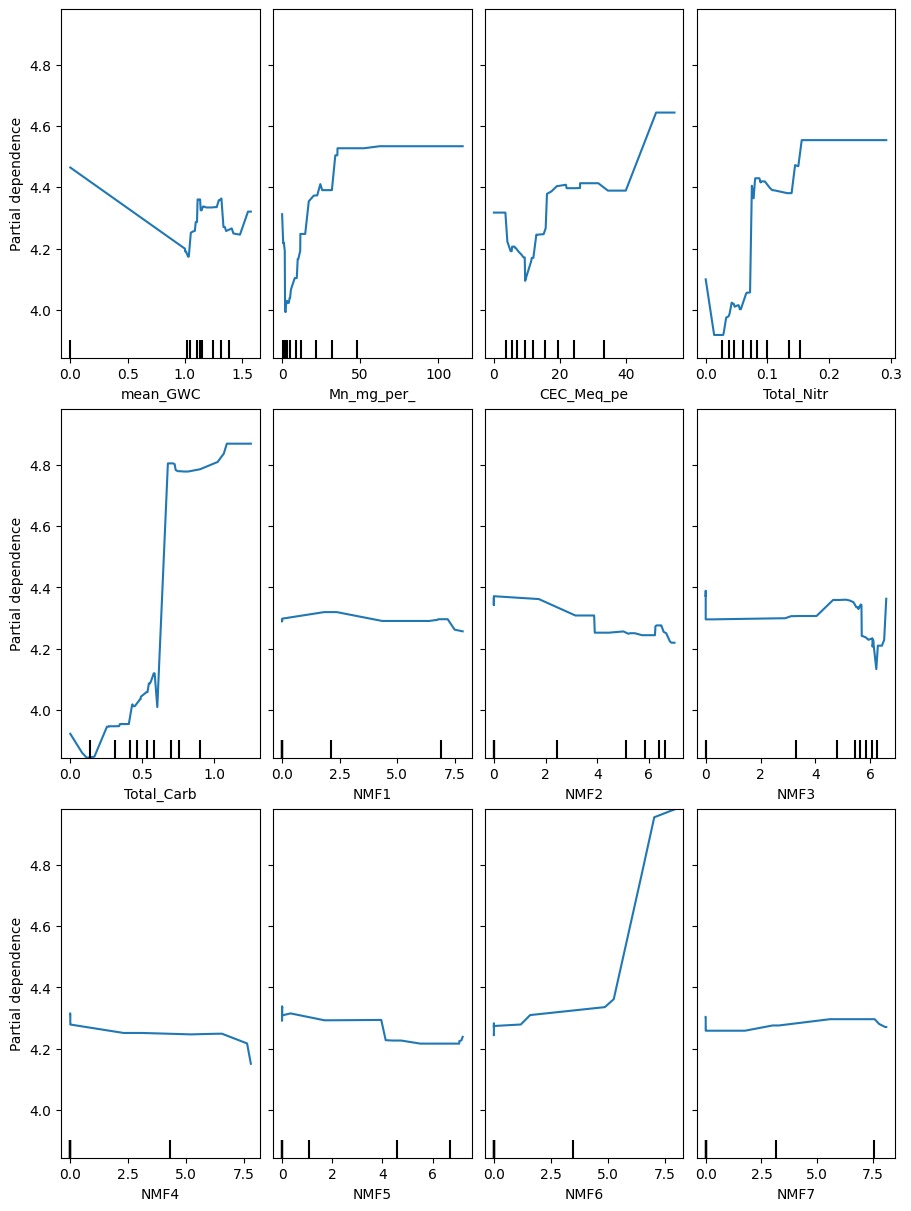

In [114]:
from sklearn.inspection import PartialDependenceDisplay
_, ax = plt.subplots(ncols=4, nrows=3, figsize=(9, 12), constrained_layout=True)
PartialDependenceDisplay.from_estimator(rsh.best_estimator_, X_train, 
                                        np.arange(0,12),feature_names=df_env_top_pred.columns,method="brute",
                                        ax=ax)
plt.show()

In [48]:
reg = GradientBoostingRegressor(ccp_alpha=0.004355064417148414, learning_rate=0.01,
                          loss='huber', max_depth=14, max_features=1,
                          min_samples_split=5, n_estimators=914,
                          random_state=0)

In [54]:
reg.fit(X_train, y_train)

GradientBoostingRegressor(ccp_alpha=0.004355064417148414, learning_rate=0.01,
                          loss='huber', max_depth=14, max_features=1,
                          min_samples_split=5, n_estimators=914,
                          random_state=0)

In [55]:
reg.score(X_test,y_test)

0.44908529859717605

In [61]:
rsh.best_score_

-0.8175009717365658

In [60]:
mean_squared_error(y_test, rsh.best_estimator_.predict(X_test), squared=False)

0.8158058015035098

In [63]:
rsh = joblib.load('/home/shic892/corems/gradient_env_6_btm_respiration_log_v1.pkl')

In [66]:
rsh.best_score_

-0.5992343754759692

In [64]:
X, y = df_env_btm_pred.values, np.log(df_env_btm['Respiratio'].iloc[:,1].values+1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [65]:
mean_squared_error(y_test, rsh.best_estimator_.predict(X_test), squared=False)

0.4619428300141958

In [81]:
rsh = joblib.load('/home/shic892/corems/gradient_env_6_nmf_5_log_btm_respiration_log_v1.pkl')

In [82]:
rsh.best_score_

-0.6678958116700546

In [71]:
df_env_btm_pred[['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5']] = np.log(datah5.T+1)
X, y = df_env_btm_pred.values, np.log(df_env_btm['Respiratio'].iloc[:,1].values+1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [84]:
mean_squared_error(y_test, rsh.best_estimator_.predict(X_test), squared=False)

0.48967754235141187

In [83]:
rsh.best_estimator_.score(X_test,y_test)

0.36284296682558537

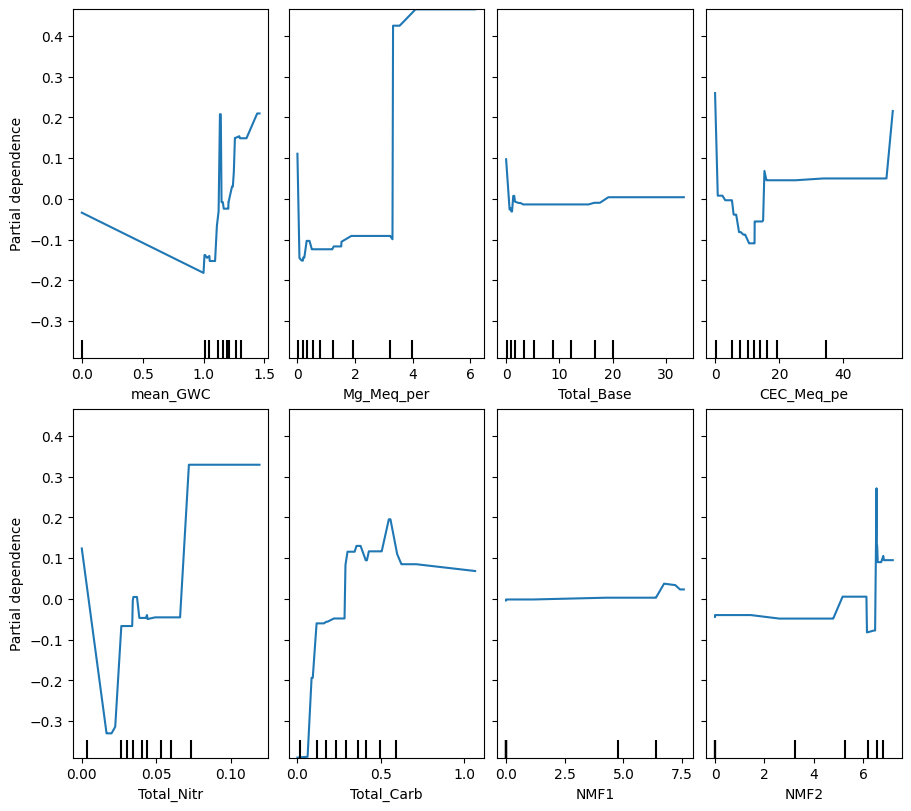

In [106]:
from sklearn.inspection import PartialDependenceDisplay
_, ax = plt.subplots(ncols=4, nrows=2, figsize=(9, 8), constrained_layout=True)
PartialDependenceDisplay.from_estimator(rsh.best_estimator_, X_train, 
                                        np.arange(0,8),feature_names=df_env_btm_pred.columns,
                                        ax=ax)
plt.show()

Index(['mean_GWC', 'Mg_Meq_per', 'Total_Base', 'CEC_Meq_pe', 'Total_Nitr',
       'Total_Carb', 'NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5'],
      dtype='object')

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
_, ax = plt.subplots(ncols=3, nrows=2, figsize=(9, 8), constrained_layout=True)
common_params = {
    "subsample": 10,
    "n_jobs": 2,
    "grid_resolution": 20,
    "random_state": 0,
}

display = PartialDependenceDisplay.from_estimator(
    rsh.best_estimator_,
    X_train,
    "features": ["temp", "humidity", "windspeed", "season", "weather", "hour"],
    ax=ax,
    **common_params,
)